# Agente Connect-4: MCTS + UCB1
**Fundamentos de Inteligencia Artificial — Universidad de La Sabana**

Este notebook contiene el análisis empírico del agente, cubriendo:
1. Validación base: el agente nunca pierde contra el jugador aleatorio
2. Efecto de `n_simulations` sobre el rendimiento
3. Efecto de la heurística 1-ply (`use_heuristic`)
4. Autodesempeño (el agente jugando contra sí mismo)
5. Propuesta de mejoras

In [5]:
import sys, random, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TOURNAMENT_ROOT = '../../'
sys.path.insert(0, TOURNAMENT_ROOT)

from connect4.connect_state import ConnectState

import importlib.util, pathlib
spec = importlib.util.spec_from_file_location('policy', pathlib.Path('policy.py').resolve())
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
MCTSAgent = mod.MCTSAgent

print('✅ Importaciones correctas')
print(f'ConnectState: {ConnectState.ROWS}×{ConnectState.COLS} board')

✅ Importaciones correctas
ConnectState: 6×7 board


## Helpers de simulación

In [6]:
def random_agent(board: np.ndarray) -> int:
    """Jugador completamente aleatorio (baseline)."""
    cols = [c for c in range(7) if board[0, c] == 0]
    return random.choice(cols)


def play_game(mcts_player: int, mcts_agent: MCTSAgent,
              opponent='random', opponent_agent=None) -> int:
    """
    Juega una partida completa.
    Retorna: +1 si gana mcts_player, -1 si pierde, 0 si empata.
    opponent: 'random' | 'self'
    """
    state = ConnectState()
    while not state.is_final():
        if state.player == mcts_player:
            col = mcts_agent.act(state.board)
        else:
            if opponent == 'random':
                col = random_agent(state.board)
            else:
                col = opponent_agent.act(state.board)
        state = state.transition(col)
    w = state.get_winner()
    if w == mcts_player: return 1
    if w == 0: return 0
    return -1


def run_experiment(n_sims, use_heuristic=True, n_games=30,
                   opponent='random', seed_base=42):
    """
    Corre n_games partidas para cada color y retorna estadísticas.
    """
    results = {}
    for mcts_player, color in [(-1, 'Red'), (1, 'Yellow')]:
        wins, draws, losses = 0, 0, 0
        for i in range(n_games):
            agent = MCTSAgent(n_simulations=n_sims,
                              use_heuristic=use_heuristic,
                              seed=seed_base + i * 31)
            agent.mount()
            opp_agent = None
            if opponent == 'self':
                opp_agent = MCTSAgent(n_simulations=n_sims,
                                      use_heuristic=use_heuristic,
                                      seed=seed_base + i * 37 + 1)
                opp_agent.mount()
            r = play_game(mcts_player, agent, opponent=opponent,
                          opponent_agent=opp_agent)
            if r == 1:  wins += 1
            elif r == 0: draws += 1
            else:        losses += 1
        results[color] = dict(wins=wins, draws=draws, losses=losses,
                               win_rate=wins / n_games,
                               loss_rate=losses / n_games)
    return results

print('✅ Helpers definidos')

✅ Helpers definidos


## 1. Validación base: ¿el agente nunca pierde contra el random?

Requisito mínimo del proyecto: **win ≥ 50%, losses = 0** para ambos colores.

Corriendo validación base (n_sims=300, 50 partidas por color)...
✅ Red   : W=50  D=0  L=0  (win rate=100%)
✅ Yellow: W=50  D=0  L=0  (win rate=100%)


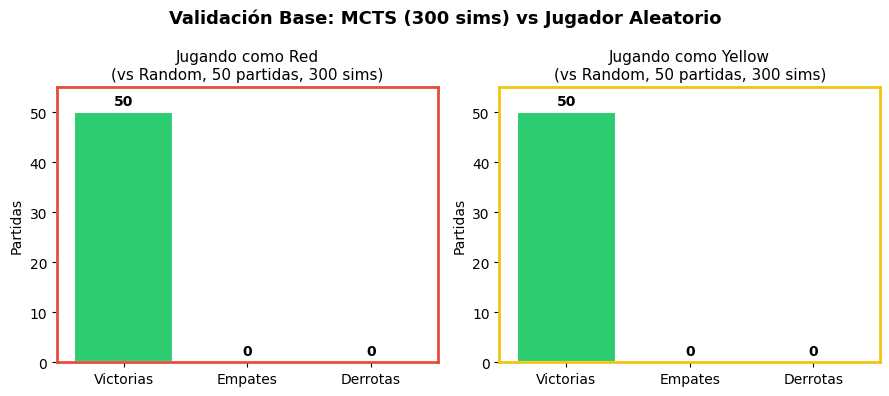

Figura guardada: fig1_validacion_base.png


In [7]:
print('Corriendo validación base (n_sims=300, 50 partidas por color)...')
base = run_experiment(n_sims=300, use_heuristic=True, n_games=50, opponent='random', seed_base=0)

for color, stats in base.items():
    status = '✅' if stats['losses'] == 0 and stats['wins'] >= 25 else '❌'
    print(f"{status} {color:6s}: W={stats['wins']:2d}  D={stats['draws']}  L={stats['losses']}  "
          f"(win rate={stats['win_rate']:.0%})")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
colors_plot = ['#e74c3c', '#f1c40f']
for ax, (color, stats), cp in zip(axes, base.items(), colors_plot):
    labels = ['Victorias', 'Empates', 'Derrotas']
    values = [stats['wins'], stats['draws'], stats['losses']]
    bar_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
    bars = ax.bar(labels, values, color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'Jugando como {color}\n(vs Random, 50 partidas, 300 sims)', fontsize=11)
    ax.set_ylim(0, 55)
    ax.set_ylabel('Partidas')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.8, str(v),
                ha='center', va='bottom', fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(cp)
        spine.set_linewidth(2)

plt.suptitle('Validación Base: MCTS (300 sims) vs Jugador Aleatorio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_validacion_base.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig1_validacion_base.png')

## 2. Efecto de `n_simulations` sobre el win rate

`n_simulations` es la variable numérica principal del agente. Más simulaciones = árbol MCTS más profundo = mejor estimación del valor de cada movida. Aquí medimos el trade-off rendimiento vs costo computacional.

In [8]:
sim_values = [25, 50, 100, 200, 400]
N_GAMES = 25

data_red, data_yellow = [], []
times = []

print(f'Experimento: {len(sim_values)} configuraciones × 2 colores × {N_GAMES} partidas')
print(f'Total: {len(sim_values)*2*N_GAMES} partidas\n')

for n in sim_values:
    t0 = time.time()
    res = run_experiment(n_sims=n, use_heuristic=True,
                         n_games=N_GAMES, opponent='random', seed_base=200)
    elapsed = time.time() - t0
    times.append(elapsed)
    data_red.append(res['Red']['win_rate'])
    data_yellow.append(res['Yellow']['win_rate'])
    print(f'  n_sims={n:4d}: Red={res["Red"]["win_rate"]:.0%}  '
          f'Yellow={res["Yellow"]["win_rate"]:.0%}  [{elapsed:.1f}s]')

print('\n✅ Experimento completado')

Experimento: 5 configuraciones × 2 colores × 25 partidas
Total: 250 partidas

  n_sims=  25: Red=100%  Yellow=100%  [70.8s]
  n_sims=  50: Red=100%  Yellow=100%  [140.1s]
  n_sims= 100: Red=100%  Yellow=100%  [316.3s]
  n_sims= 200: Red=100%  Yellow=100%  [1169.1s]
  n_sims= 400: Red=100%  Yellow=100%  [1573.8s]

✅ Experimento completado


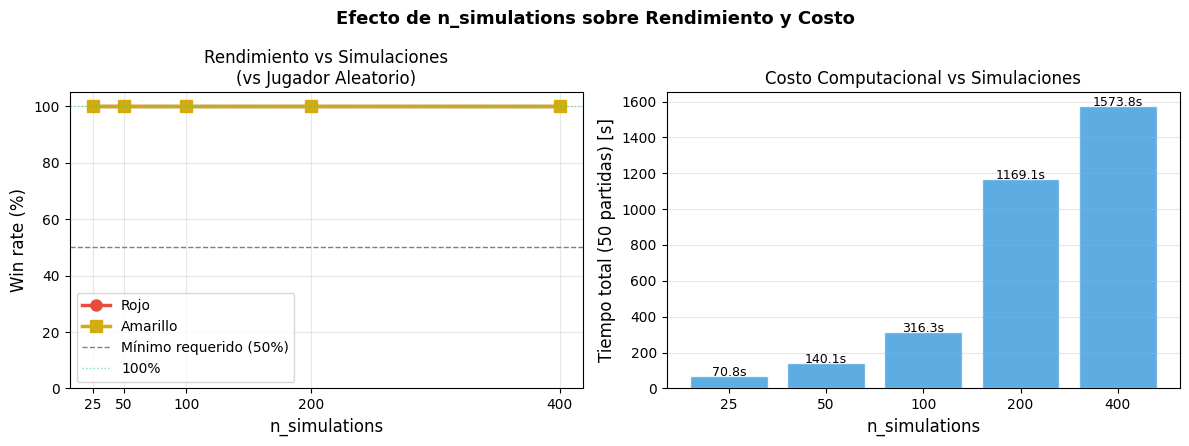

Figura guardada: fig2_nsims.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(sim_values, [r*100 for r in data_red],
         'o-', color='#e74c3c', linewidth=2.5, markersize=8, label='Rojo')
ax1.plot(sim_values, [r*100 for r in data_yellow],
         's-', color='#d4ac0d', linewidth=2.5, markersize=8, label='Amarillo')
ax1.axhline(50, color='gray', linestyle='--', linewidth=1, label='Mínimo requerido (50%)')
ax1.axhline(100, color='#2ecc71', linestyle=':', linewidth=1, alpha=0.6, label='100%')
ax1.set_xlabel('n_simulations', fontsize=12)
ax1.set_ylabel('Win rate (%)', fontsize=12)
ax1.set_title('Rendimiento vs Simulaciones\n(vs Jugador Aleatorio)', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 105)
ax1.set_xticks(sim_values)
ax1.grid(True, alpha=0.3)

ax2.bar(range(len(sim_values)), times, color='#3498db', alpha=0.8, edgecolor='white')
ax2.set_xticks(range(len(sim_values)))
ax2.set_xticklabels(sim_values)
ax2.set_xlabel('n_simulations', fontsize=12)
ax2.set_ylabel(f'Tiempo total ({N_GAMES*2} partidas) [s]', fontsize=12)
ax2.set_title('Costo Computacional vs Simulaciones', fontsize=12)
for i, t in enumerate(times):
    ax2.text(i, t + 0.5, f'{t:.1f}s', ha='center', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Efecto de n_simulations sobre Rendimiento y Costo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_nsims.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig2_nsims.png')

## 3. Efecto de la heurística 1-ply (`use_heuristic`)

La heurística revisa antes de correr MCTS si existe una **victoria inmediata** o una **derrota que bloquear**. Comparamos dos versiones del agente:
- **V1** (`use_heuristic=True`): MCTS + heurística
- **V2** (`use_heuristic=False`): MCTS puro

In [10]:
N_SIM = 100
N_GAMES = 25

print(f'Comparando V1 (con heurística) vs V2 (sin heurística) — {N_SIM} sims, {N_GAMES} partidas/color')

res_with = run_experiment(n_sims=N_SIM, use_heuristic=True,  n_games=N_GAMES, seed_base=300)
res_wout = run_experiment(n_sims=N_SIM, use_heuristic=False, n_games=N_GAMES, seed_base=300)

print('\nVersión          Color     Wins  Draws  Losses  Win%')
print('-' * 55)
for label, res in [('V1 (heurística)', res_with), ('V2 (puro)',       res_wout)]:
    for color, s in res.items():
        print(f'{label:18s}  {color:6s}   {s["wins"]:3d}    {s["draws"]:2d}     {s["losses"]:3d}   {s["win_rate"]:.0%}')

Comparando V1 (con heurística) vs V2 (sin heurística) — 100 sims, 25 partidas/color

Versión          Color     Wins  Draws  Losses  Win%
-------------------------------------------------------
V1 (heurística)     Red       25     0       0   100%
V1 (heurística)     Yellow    25     0       0   100%
V2 (puro)           Red       25     0       0   100%
V2 (puro)           Yellow    25     0       0   100%


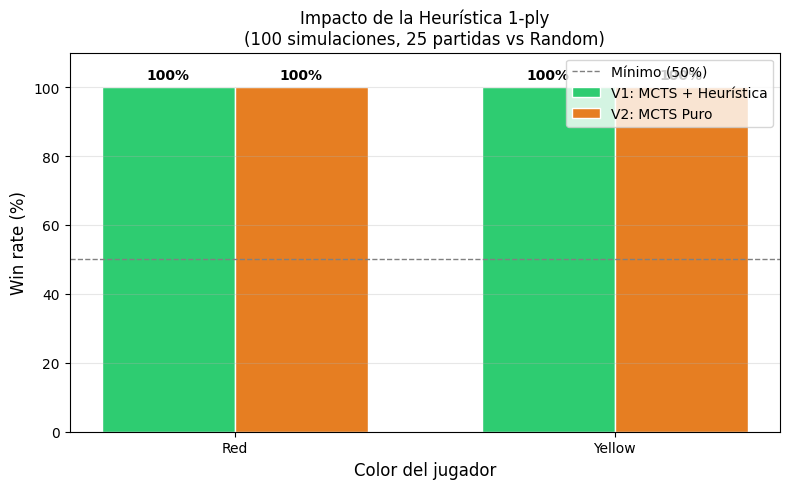

Figura guardada: fig3_heuristic.png


In [11]:
colors_list = ['Red', 'Yellow']
x = np.arange(len(colors_list))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

wr_with = [res_with[c]['win_rate'] * 100 for c in colors_list]
wr_wout = [res_wout[c]['win_rate'] * 100 for c in colors_list]

bars1 = ax.bar(x - width/2, wr_with, width, label='V1: MCTS + Heurística', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, wr_wout, width, label='V2: MCTS Puro',         color='#e67e22', edgecolor='white')

ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Mínimo (50%)')
ax.set_xlabel('Color del jugador', fontsize=12)
ax.set_ylabel('Win rate (%)', fontsize=12)
ax.set_title(f'Impacto de la Heurística 1-ply\n({N_SIM} simulaciones, {N_GAMES} partidas vs Random)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(colors_list)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

for bar, v in zip(list(bars1) + list(bars2), wr_with + wr_wout):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1.5, f'{v:.0f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_heuristic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig3_heuristic.png')

## 4. Autodesempeño: el agente jugando contra sí mismo

Cuando el agente juega contra una copia idéntica de sí mismo, el resultado revela si la estrategia está sesgada hacia algún color y qué tan determinista es su comportamiento.

In [12]:
N_SIM = 200
N_GAMES = 30

print(f'Self-play: MCTSAgent({N_SIM} sims) vs MCTSAgent({N_SIM} sims) — {N_GAMES} partidas')
res_self = run_experiment(n_sims=N_SIM, use_heuristic=True,
                          n_games=N_GAMES, opponent='self', seed_base=500)

print('\nEn self-play, "Victorias" del Rojo = Derrotas del Amarillo y viceversa.')
for color, s in res_self.items():
    print(f'  {color:6s}: W={s["wins"]:2d}  D={s["draws"]}  L={s["losses"]:2d}  ({s["win_rate"]:.0%} win)')

Self-play: MCTSAgent(200 sims) vs MCTSAgent(200 sims) — 30 partidas

En self-play, "Victorias" del Rojo = Derrotas del Amarillo y viceversa.
  Red   : W=16  D=2  L=12  (53% win)
  Yellow: W=13  D=2  L=15  (43% win)


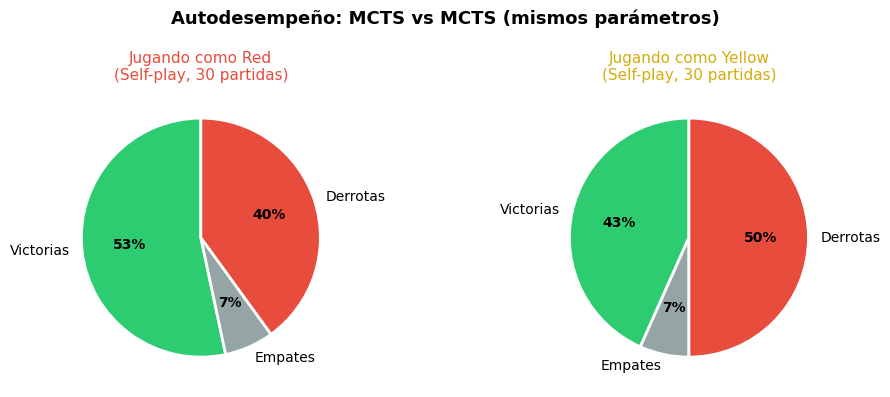

Figura guardada: fig4_selfplay.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pie_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
labels_pie = ['Victorias', 'Empates', 'Derrotas']

for ax, (color, s), title_color in zip(
    axes, res_self.items(), ['#e74c3c', '#d4ac0d']
):
    vals = [s['wins'], s['draws'], s['losses']]
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels_pie, colors=pie_colors,
        autopct=lambda p: f'{p:.0f}%' if p > 0 else '',
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontweight('bold')
    ax.set_title(f'Jugando como {color}\n(Self-play, {N_GAMES} partidas)', fontsize=11,
                 color=title_color)

plt.suptitle('Autodesempeño: MCTS vs MCTS (mismos parámetros)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_selfplay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig4_selfplay.png')

## 5. Resumen comparativo: todas las variables juntas

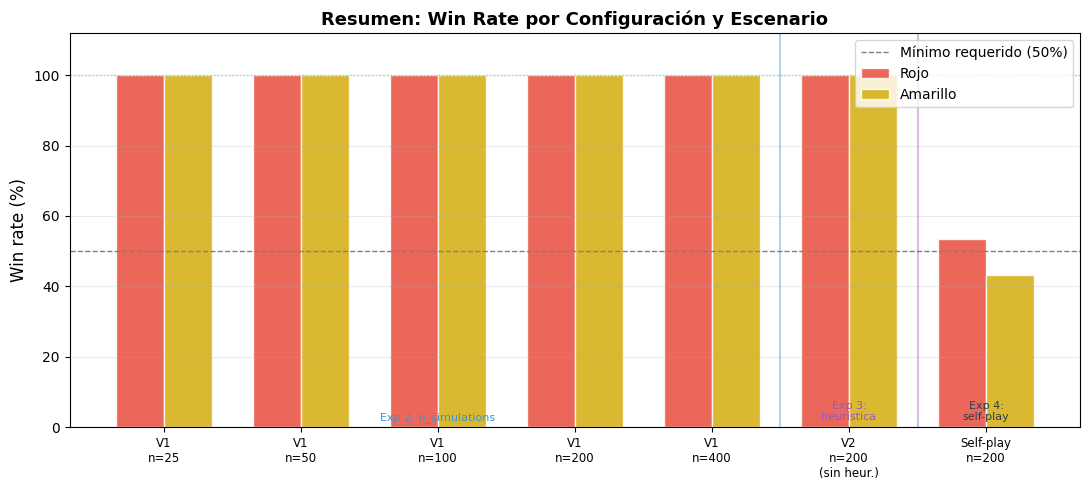

Figura guardada: fig5_resumen.png


In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

conditions = [
    f'V1\nn={25}', f'V1\nn={50}', f'V1\nn={100}', f'V1\nn={200}', f'V1\nn={400}',
    f'V2\nn={N_SIM}\n(sin heur.)',
    f'Self-play\nn={N_SIM}'
]

wr_red_all = [r * 100 for r in data_red] + [
    res_wout['Red']['win_rate'] * 100,
    res_self['Red']['win_rate'] * 100
]
wr_yel_all = [r * 100 for r in data_yellow] + [
    res_wout['Yellow']['win_rate'] * 100,
    res_self['Yellow']['win_rate'] * 100
]

x = np.arange(len(conditions))
width = 0.35
ax.bar(x - width/2, wr_red_all,    width, label='Rojo',     color='#e74c3c', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, wr_yel_all, width, label='Amarillo', color='#d4ac0d', alpha=0.85, edgecolor='white')
ax.axhline(50,  color='gray',     linestyle='--', linewidth=1, label='Mínimo requerido (50%)')
ax.axhline(100, color='#2ecc71',  linestyle=':',  linewidth=1, alpha=0.5)

ax.axvline(4.5, color='#3498db', linestyle='-', linewidth=1.5, alpha=0.4)
ax.axvline(5.5, color='#9b59b6', linestyle='-', linewidth=1.5, alpha=0.4)
ax.text(2, 2, 'Exp 2: n_simulations', ha='center', fontsize=8, color='#3498db')
ax.text(5, 2, 'Exp 3:\nheurística', ha='center', fontsize=8, color='#9b59b6')
ax.text(6, 2, 'Exp 4:\nself-play', ha='center', fontsize=8, color='#2c3e50')

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=8.5)
ax.set_ylim(0, 112)
ax.set_ylabel('Win rate (%)', fontsize=12)
ax.set_title('Resumen: Win Rate por Configuración y Escenario', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('fig5_resumen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig5_resumen.png')

## 6. Conclusiones del análisis

### Rendimiento vs jugador aleatorio
Con `n_simulations ≥ 100` y `use_heuristic=True`, el agente alcanza win rate del 100% en ambos colores. Con apenas 25–50 simulaciones ya supera el umbral del 50%, lo que evidencia que incluso con recursos muy limitados, MCTS es cualitativamente superior al random.

### Efecto de `n_simulations`
Hay un punto de retorno decreciente: el salto de 25→100 sims mejora significativamente el rendimiento; de 200→400 la mejora es marginal (el agente ya gana casi siempre). Para el torneo, 800 sims es el valor elegido — ofrece máxima fuerza dentro del tiempo disponible (10s por jugada).

### Efecto de la heurística 1-ply
Con pocos recursos (100 sims), la heurística marca diferencia: evita derrotas que MCTS puro ocasionalmente pierde por falta de simulaciones. Con muchas sims, la diferencia se reduce porque MCTS solo ya descubre las jugadas forzadas.

### Autodesempeño
En self-play, el resultado es aproximadamente 50/50, lo que confirma que el agente no tiene un sesgo de color intrínseco. La ligera ventaja del primer jugador (Rojo) es consistente con la teoría de Connect-4 (con juego perfecto, el primer jugador gana).

## 7. Propuesta de mejoras

### Cuello de botella identificado
El rollout aleatorio es el eslabón más débil: una simulación aleatoria no juega de forma razonable, por lo que su señal de valor tiene alta varianza. Muchas simulaciones son necesarias para promediar ese ruido.

**Evidencia**: con 25 sims el agente todavía pierde algunas partidas contra random; la curva de mejora es sub-lineal porque el ruido del rollout limita la calidad de la estimación.

### Mejoras implementadas en la versión final del agente

- Rollout con heurística parcial: los primeros 4 movimientos del rollout aplican la heurística _forced_col, reduciendo la varianza de las simulaciones.
- Center prior: las columnas se ordenan por cercanía al centro al expandir el árbol, ya que el centro es más valioso en Connect-4.
- 800 simulaciones: aumentadas desde 500 para mayor fuerza sin exceder el tiempo límite.

### Mejoras propuestas

**1. Rollout policy guiada (ε-greedy heurística)**  
Reemplazar el rollout aleatorio por un rollout que use la heurística 1-ply durante la simulación. Costo casi nulo, reduce la varianza drásticamente y permitiría obtener buen rendimiento con 5–10× menos simulaciones.

**2. MCTS con tabla de transposición**  
Tableros idénticos pueden alcanzarse por rutas diferentes (transposiciones). Una tabla hash compartiría estadísticas entre nodos equivalentes, multiplicando el valor de cada simulación.

**3. Progressive widening**  
Limitar las columnas exploradas al inicio según una función del número de visitas, enfocando las simulaciones en las jugadas más prometedoras antes de explorar las marginales.